## 📘 MILP Benchmark Problem: *gen-ip002* (MIPLIB)

The **gen-ip002** instance is a benchmark problem from the **MIPLIB** (Mixed Integer Programming LIBrary) repository. It is categorized as a **pure integer programming problem**, meaning all decision variables are integer-valued and some may take values beyond binary. This class of problems is widely used to evaluate MILP solvers on discrete optimization tasks that involve integer (but not necessarily binary) decisions.

🔗 Problem page:  
https://miplib.zib.de/instance_details_gen-ip002.html

---

### 🧮 Problem Structure

According to the MIPLIB instance details:

- **Decision variables:** 823  
- **Binary variables:** 0  
- **General integer variables:** 823  
- **Continuous variables:** 0  
- **Constraints:** 555  
- **Constraint nonzeros (matrix entries):** 4251  
- **Problem type:** Pure Integer  
- **Constraint types:** Linear

This means that:
- All 823 variables are **general integer** (not restricted to 0/1).  
- There are **no continuous or binary-only variables** in this instance.  
- Every decision must satisfy integer constraints.

As with other MIPLIB instances, this problem is expressed in **linear form**, with a **linear objective** and **linear constraints**.

---

### 🧠 Mathematical Formulation (Abstract)

The gen-ip002 instance can be expressed in the standard integer programming form:

$$
\begin{aligned}
\min\quad & c^\top x \\
\text{s.t.}\quad & A x \le b, \\
& x_j \in \mathbb{Z} \quad \forall j = 1,\ldots,823,
\end{aligned}
$$

where:
- $x = (x_1,\dots,x_{823}) $ is the integer decision vector,
- $c$ is the cost coefficient vector,
- $A$ is the constraint coefficient matrix,
-$b$ is the right-hand side vector.

There are **no binary variables** in this instance; all variables are **integer**, typically with explicit lower and upper bounds specified in the MPS file.

---

### 🧩 Why This Instance Is Interesting

The *gen-ip002* instance is noteworthy for several reasons:

- It is a **pure integer program** without binaries or continuous parts. This makes it fundamentally different from 0/1 selection problems and more similar to classical integer resource allocation or counting problems.
- With **823 integer variables** and **555 constraints**, it is moderately large and can exhibit considerable combinatorial complexity.
- The structure of pure integer problems often leads to **significant branching effort** because there is no LP relaxation where fractions can be easily rounded; integrality must be resolved directly.
- The large number of integer variables makes it a good case for studying branch-and-bound performance, cut generation, and solver heuristics beyond simple binary decisions.

---

### ⚙️ Solver Behavior and Expected Difficulty

For pure integer problems like this:
- The **LP relaxation can be weak**, and so the solver may need extensive branching to find and prove optimality.
- Heuristic improvement and bound strengthening play a key role in solution progress.
- The problem often produces **interesting callback behavior** that is well suited for visualization (e.g., objective progression over time).

The notebook can be used to:
- run Gurobi with callbacks,
- visualize objective vs time,
- plot best bound and gap progression,
- measure solver node and cut statistics.

---

### 🗂 What You Will Analyze in This Notebook

This notebook applies the following methodology to the *gen-ip002* instance:

1. **Load the MPS file** directly with Gurobi  
2. **Track solver progress** using callbacks (incumbent objective, best bound, node counts)  
3. **Plot convergence graphs** (e.g., objective vs time, gap vs time, node count vs bound)  
4. **Interpret solver behavior** and discuss performance  
5. **Export results** (solution files, parsed models)

These analyses are not only useful for this instance, but also illustrate general techniques for benchmarking integer optimization problems.

---

### 📌 References

This benchmark is part of the MIPLIB library, a long-standing repository of mixed and integer programming instances maintained by the Zuse Institute Berlin. MIPLIB problems are designed to challenge modern solvers and originate from real applications and carefully crafted academic examples.

(Link: https://miplib.zib.de/)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 56.9 MB/s eta 0:00:00
Restricted license - for non-production use only - expires 2027-11-29
Read MPS format model from file /content/integer_gen-ip002.mps
Reading time = 0.00 seconds
gen-ip002: 24 rows, 41 columns, 922 nonzeros
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 24 rows, 41 columns and 922 nonzeros (Min)
Model fingerprint: 0xec28dfc4
Model has 41 linear objective coefficients
Variable types: 0 continuous, 41 integer (0 binary)
Coefficient statistics:
  Matrix range     [3e-03, 2e+01]
  Objective range  [7e+00, 3e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [7e+01, 3e+02]
Found heuristic solution: objective -2861.466511
Found heuristic solution: objective -2917.373

/tmp/ipython-input-1928254785.py:60: RuntimeWarning: invalid value encountered in log
  plt.plot(times, np.log(incumbents), marker="o", label="Incumbent")
/tmp/ipython-input-1928254785.py:61: RuntimeWarning: invalid value encountered in log
  plt.plot(times, np.log(bounds), linestyle="--", label="Best bound")


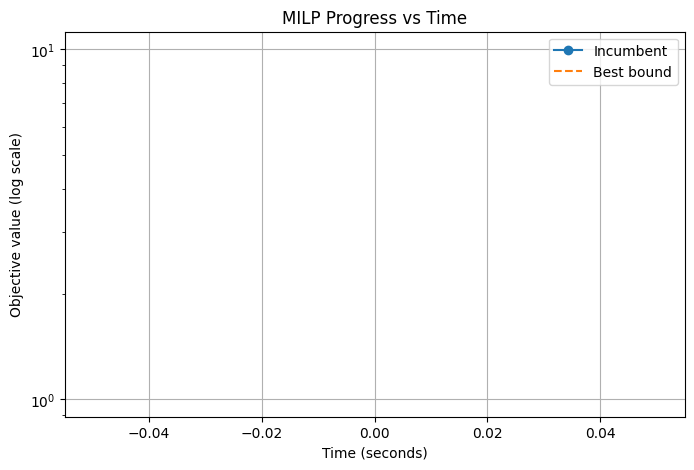

/tmp/ipython-input-1928254785.py:75: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


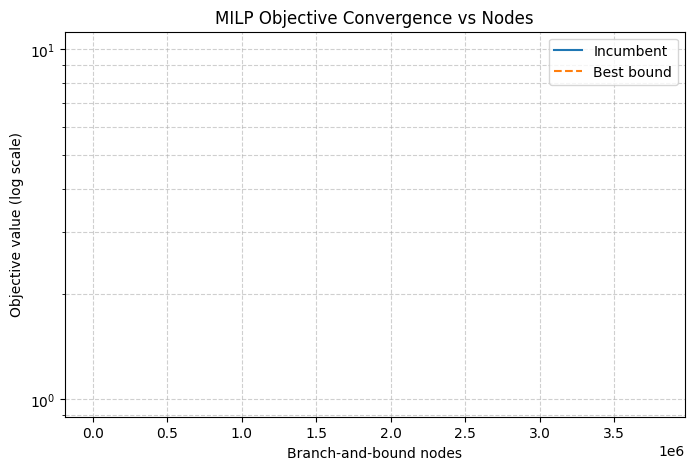

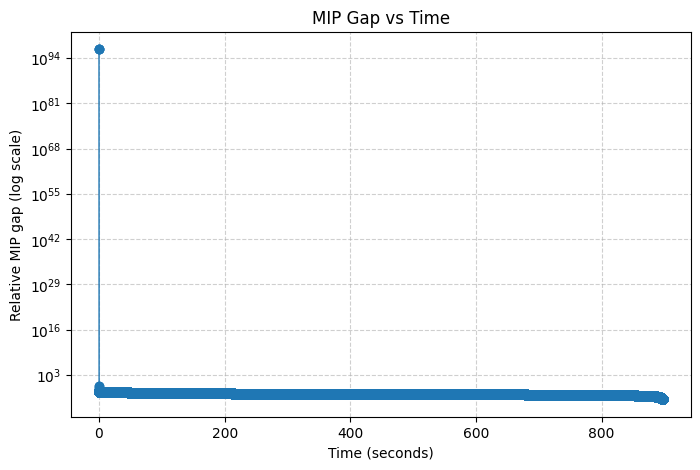

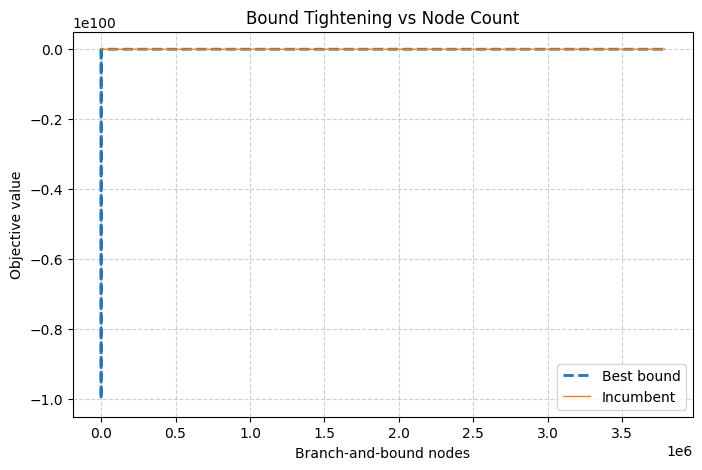

In [1]:
!pip -q install gurobipy

import os
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import numpy as np

mps_path = "/content/integer_gen-ip002.mps"
if not os.path.exists(mps_path):
    raise FileNotFoundError(f"Not found: {mps_path}")

m = gp.read(mps_path)
m.Params.OutputFlag = 1

# --- storage ---
times = []
nodes = []
incumbents = []
bounds = []
events = []

def cb(model, where):
    # Record new feasible solutions (incumbent improvements)
    if where == GRB.Callback.MIPSOL:
        t = model.cbGet(GRB.Callback.RUNTIME)
        n = model.cbGet(GRB.Callback.MIPSOL_NODCNT)
        obj = model.cbGet(GRB.Callback.MIPSOL_OBJ)
        bnd = model.cbGet(GRB.Callback.MIPSOL_OBJBND)

        times.append(t); nodes.append(n)
        incumbents.append(obj); bounds.append(bnd)
        events.append("MIPSOL")

    # Record periodic progress (bound updates)
    elif where == GRB.Callback.MIP:
        t = model.cbGet(GRB.Callback.RUNTIME)
        n = model.cbGet(GRB.Callback.MIP_NODCNT)
        obj_best = model.cbGet(GRB.Callback.MIP_OBJBST)
        obj_bnd  = model.cbGet(GRB.Callback.MIP_OBJBND)

        if obj_best < GRB.INFINITY:
            times.append(t); nodes.append(n)
            incumbents.append(obj_best); bounds.append(obj_bnd)
            events.append("MIP")

# Run once with callback
m.optimize(cb)

print("Collected points:", len(times))
print("Status:", m.Status)
if m.SolCount > 0:
    print("Objective:", m.ObjVal)
    m.write("/content/solution.sol")
    m.write("/content/model_parsed.lp")
    print("Wrote: /content/solution.sol and /content/model_parsed.lp")

# ---- Plot: Objective vs time ----
plt.figure(figsize=(8,5))
plt.plot(times, np.log(incumbents), marker="o", label="Incumbent")
plt.plot(times, np.log(bounds), linestyle="--", label="Best bound")
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Progress vs Time")
plt.grid(True)
plt.legend()
plt.show()

# ---- Plot: Objective vs nodes ----
plt.figure(figsize=(8,5))
plt.plot(nodes, incumbents, label="Incumbent")
plt.plot(nodes, bounds, linestyle="--", label="Best bound")

plt.yscale("log")
plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Objective Convergence vs Nodes")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# As the search for the optimum advnaces, the integrality gap minimizes.

# Convert to numpy arrays
t = np.asarray(times, dtype=float)
inc = np.asarray(incumbents, dtype=float)
bnd = np.asarray(bounds, dtype=float)

# Safety: keep only finite entries
mask = np.isfinite(t) & np.isfinite(inc) & np.isfinite(bnd)
t, inc, bnd = t[mask], inc[mask], bnd[mask]

# Relative gap for minimization
eps = 1e-12
gap = (inc - bnd) / np.maximum(np.abs(inc), eps)

# Clip to avoid log(0) and negative values due to numerical noise
gap = np.maximum(gap, 1e-12)

# Optional: sort by time (sometimes callback gives non-monotone due to mixed events)
order = np.argsort(t)
t, gap = t[order], gap[order]

plt.figure(figsize=(8,5))
plt.plot(t, gap, marker="o", linewidth=1)
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Relative MIP gap (log scale)")
plt.title("MIP Gap vs Time")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show()

# plot for Node count vs Best bound (and optional incumbent)
# This plot shows how the lower bound tightens as branch-and-bound explores nodes

n = np.asarray(nodes, dtype=float)
inc = np.asarray(incumbents, dtype=float)
bnd = np.asarray(bounds, dtype=float)

mask = np.isfinite(n) & np.isfinite(inc) & np.isfinite(bnd)
n, inc, bnd = n[mask], inc[mask], bnd[mask]

# Sort by node count
order = np.argsort(n)
n, inc, bnd = n[order], inc[order], bnd[order]

plt.figure(figsize=(8,5))

# Best bound vs nodes (main request)
plt.plot(n, bnd, linestyle="--", linewidth=2, label="Best bound")

# Optional: include incumbent for context
plt.plot(n, inc, linewidth=1, label="Incumbent")

plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value")
plt.title("Bound Tightening vs Node Count")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()
